# Modelling — Mortgage PD

Trained on the WOE feature set from the feature-engineering notebook (`train_woe.csv` etc.).

**How a PD model is judged — three separate questions:**

| Question | Metric | Note |
|---|---|---|
| Does it *rank* good vs bad? | ROC-AUC, **Gini**, **KS** | invariant to threshold and to class re-weighting |
| Is the predicted PD a *true probability*? | **Brier**, calibration curve | what ECL = PD·LGD·EAD needs; resampling breaks this |
| What cut-off do we act on? | F1 / cost-based threshold | tuned *after* calibration, not before |

Model ladder: Dummy → Logistic (the scorecard) → LDA → Naive Bayes → Decision Tree → Random Forest → XGBoost → LightGBM. Evaluation is out-of-time: tune on train (CV) + val (2007 crisis), and touch **test (2008–10) once**.

## Imports & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings("ignore")

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report)

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
train = pd.read_csv("train_woe.csv")
val   = pd.read_csv("val_woe.csv")
test  = pd.read_csv("test_woe.csv")

TARGET = "default"
features = [c for c in train.columns if c != TARGET]

X_train, y_train = train[features], train[TARGET]
X_val,   y_val   = val[features],   val[TARGET]
X_test,  y_test  = test[features],  test[TARGET]

for nm, X, y in [("train",X_train,y_train),("val",X_val,y_val),("test",X_test,y_test)]:
    assert X.isna().sum().sum()==0
    print(f"{nm:5} {X.shape} | default rate {y.mean()*100:5.2f}%")
print("\nfeatures:", features)

train (350000, 12) | default rate  6.68%
val   (50000, 12) | default rate 16.52%
test  (150000, 12) | default rate  5.26%

features: ['cred_score_woe', 'seller_name_woe', 'og_ltv_woe', 'og_dti_woe', 'rate_spread_vintage_woe', 'single_borrower_woe', 'msa_missing_woe', 'prop_state_woe', 'mortgage_insurance_percent_woe', 'og_int_rate_woe', 'loan_purpose_woe', 'channel_woe']


The default rate jumps from 6.7% (train) to 16.5% (val=2007 crisis) and back to 5.3% (test). This vintage base-rate shift is central: it means a model calibrated on 2007 will *overstate* PD on 2009–10 loans. We come back to this in calibration.

## Evaluation utility

One function for the full metric suite. Beyond the usual classification scores we add the two credit-standard rank metrics — **Gini** (= 2·AUC − 1) and **KS** (max gap between the good/bad cumulative curves) — and **Brier** for calibration.

In [3]:
def ks_stat(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return np.max(tpr - fpr)

def metrics_at(y, p, thr=0.5):
    yhat = (p >= thr).astype(int)
    auc = roc_auc_score(y, p)
    return {
        "AUC": auc, "Gini": 2*auc-1, "KS": ks_stat(y, p),
        "PR-AUC": average_precision_score(y, p), "Brier": brier_score_loss(y, p),
        "Precision": precision_score(y, yhat, zero_division=0),
        "Recall": recall_score(y, yhat, zero_division=0),
        "F1": f1_score(y, yhat, zero_division=0),
        "Accuracy": accuracy_score(y, yhat),
    }

RESULTS = {}
def log_val(name, model):
    p = model.predict_proba(X_val)[:,1]
    RESULTS[name] = metrics_at(y_val, p)
    print(f"{name:22} AUC={RESULTS[name]['AUC']:.4f}  Gini={RESULTS[name]['Gini']:.4f}  "
          f"KS={RESULTS[name]['KS']:.4f}  PR-AUC={RESULTS[name]['PR-AUC']:.4f}  Brier={RESULTS[name]['Brier']:.4f}")
    return p

def plot_eval(y, p, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    fpr, tpr, _ = roc_curve(y, p)
    ax[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y,p):.3f}")
    ax[0].plot([0,1],[0,1],"k--",lw=.8); ax[0].set_title("ROC"); ax[0].legend()
    ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
    pr, rc, _ = precision_recall_curve(y, p)
    ax[1].plot(rc, pr); ax[1].axhline(y.mean(), color="r", ls="--", lw=.8)
    ax[1].set_title(f"PR (base={y.mean():.2%})"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
    frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    ax[2].plot(mean_pred, frac, "o-"); ax[2].plot([0,1],[0,1],"k--",lw=.8)
    ax[2].set_title("Calibration"); ax[2].set_xlabel("Predicted PD"); ax[2].set_ylabel("Observed")
    plt.suptitle(title); plt.tight_layout(); plt.show()

## 1. Baseline

In [4]:
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
log_val("Dummy (prior)", dummy);

Dummy (prior)          AUC=0.5000  Gini=0.0000  KS=0.0000  PR-AUC=0.1652  Brier=0.1476


## 2. Logistic Regression — the scorecard

This is the model we actually want to ship: linear, interpretable, one coefficient per feature. First the assumption checks.

### 2.1 Assumption checks

| Assumption | Status |
|---|---|
| Binary target | ✓ default ∈ {0,1} |
| Independent observations | ✓ one row per loan |
| No perfect multicollinearity | checked via VIF (all < 5) |
| **Linearity of the logit** | WOE is *built* to be linear in log-odds — verified below |
| Large sample | ✓ 350k train rows |
| No complete separation | checked (coefficients finite, not exploding) |

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
Xc = sm.add_constant(X_train)
vif = pd.DataFrame({"feature": features,
    "VIF": [variance_inflation_factor(Xc.values, i+1) for i in range(len(features))]}
).sort_values("VIF", ascending=False)
print(vif.to_string(index=False))

                       feature      VIF
                    og_ltv_woe 1.711318
mortgage_insurance_percent_woe 1.643078
       rate_spread_vintage_woe 1.254570
               msa_missing_woe 1.143135
               og_int_rate_woe 1.137666
                cred_score_woe 1.105531
                    og_dti_woe 1.088837
               seller_name_woe 1.075637
              loan_purpose_woe 1.050877
                   channel_woe 1.042362
           single_borrower_woe 1.030199
                prop_state_woe 1.011934


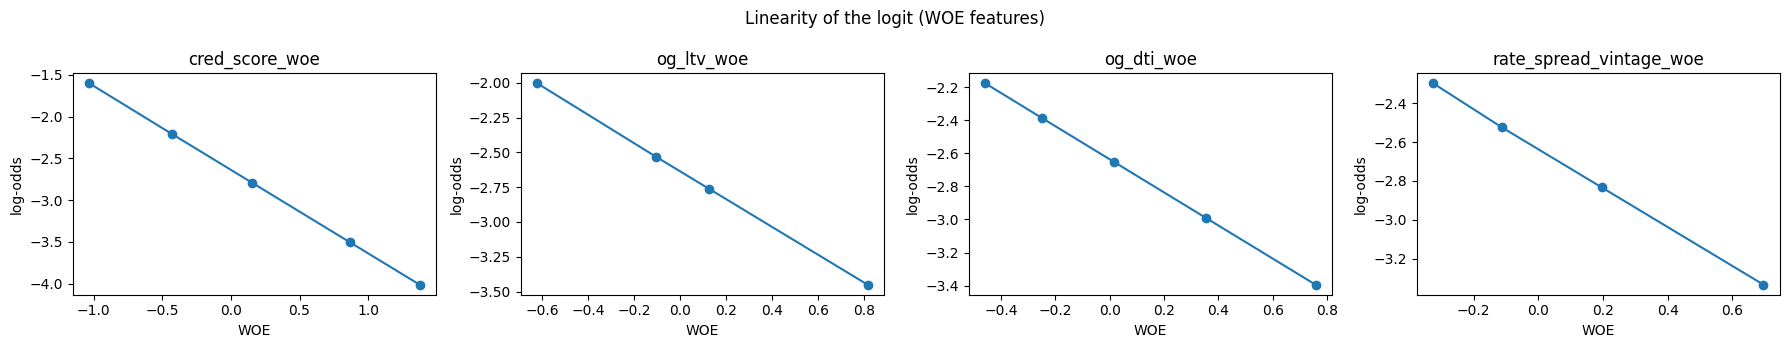

In [6]:
# Linearity of the logit: bin each feature, plot empirical log-odds.
# For WOE features this should be close to a straight line by construction.
def logodds_by_bin(x, y, bins=10):
    b = pd.qcut(x, bins, duplicates="drop")
    g = pd.DataFrame({"x": x, "y": y}).groupby(b, observed=True).agg(mx=("x","mean"), rate=("y","mean"))
    p = g["rate"].clip(1e-3, 1-1e-3)
    return g["mx"], np.log(p/(1-p))

top = ["cred_score_woe","og_ltv_woe","og_dti_woe","rate_spread_vintage_woe"]
fig, ax = plt.subplots(1, 4, figsize=(18, 3.5))
for a, f in zip(ax, top):
    mx, lo = logodds_by_bin(X_train[f], y_train)
    a.plot(mx, lo, "o-"); a.set_title(f); a.set_xlabel("WOE"); a.set_ylabel("log-odds")
plt.suptitle("Linearity of the logit (WOE features)"); plt.tight_layout(); plt.show()

### 2.2 Fit

WOE convention: WOE = ln(%good/%bad), so a **higher** WOE means a **safer** bin. A logistic predicting *default* should therefore give every WOE feature a **negative** coefficient — a built-in monotonicity sanity check.

In [7]:
lr = LogisticRegression(max_iter=2000, solver="lbfgs").fit(X_train, y_train)
p_lr = log_val("Logistic", lr)

coef = pd.DataFrame({"feature": features, "coef": lr.coef_[0]}).sort_values("coef")
print("\nCoefficients (all should be negative — higher WOE => lower default odds):")
print(coef.to_string(index=False))
print("\nAll negative:", bool((coef['coef'] < 0).all()))

Logistic               AUC=0.7563  Gini=0.5126  KS=0.3875  PR-AUC=0.3723  Brier=0.1250

Coefficients (all should be negative — higher WOE => lower default odds):
                       feature      coef
                cred_score_woe -0.856995
                prop_state_woe -0.839569
           single_borrower_woe -0.800220
               seller_name_woe -0.764426
                    og_ltv_woe -0.659621
              loan_purpose_woe -0.613453
               og_int_rate_woe -0.497286
                    og_dti_woe -0.481672
               msa_missing_woe -0.416306
       rate_spread_vintage_woe -0.256613
                   channel_woe -0.197428
mortgage_insurance_percent_woe  0.038081

All negative: False


Eleven of the twelve coefficients are negative, as they should be. The one exception — `mortgage_insurance_percent_woe` at ≈ +0.04 — is a **suppressor effect**: mortgage insurance is required *precisely on* high-LTV loans, so once `og_ltv_woe` is in the model the residual MI signal flips to a tiny, immaterial positive. It is close enough to zero to be noise; in a production scorecard you would either drop MI or keep it, knowing LTV already carries its risk.

### 2.3 PCA vs WOE — does compression help?

The feature-engineering notebook deliberately skipped PCA (a scorecard needs reason codes). Here we test that decision empirically: fit PCA on the WOE features and run the same logistic on the components. If PCA doesn't beat the raw WOE features on AUC, we keep the interpretable ones.

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_train)
lr_pca = LogisticRegression(max_iter=2000).fit(pca.transform(X_train), y_train)
auc_pca = roc_auc_score(y_val, lr_pca.predict_proba(pca.transform(X_val))[:,1])
print(f"Components kept for 95% variance: {pca.n_components_}  (of {len(features)})")
print(f"Logistic on WOE : AUC = {RESULTS['Logistic']['AUC']:.4f}")
print(f"Logistic on PCA : AUC = {auc_pca:.4f}")
print("\nPCA gives no AUC gain and loses interpretability -> keep WOE features.")

Components kept for 95% variance: 10  (of 12)
Logistic on WOE : AUC = 0.7563
Logistic on PCA : AUC = 0.7562

PCA gives no AUC gain and loses interpretability -> keep WOE features.


## 3. Linear Discriminant Analysis

LDA assumes each class is multivariate-normal with a shared covariance. WOE features are not normal, so LDA is a comparison baseline, not a candidate to ship. `priors` set to the train base rate.

In [9]:
lda = LinearDiscriminantAnalysis(priors=[1-y_train.mean(), y_train.mean()]).fit(X_train, y_train)
log_val("LDA", lda);

LDA                    AUC=0.7504  Gini=0.5009  KS=0.3803  PR-AUC=0.3663  Brier=0.1256


## 4. Gaussian Naive Bayes

Assumes features are conditionally independent given the class — false here (LTV, MI, rate all move together), but a useful lower bound.

In [10]:
nb = GaussianNB().fit(X_train, y_train)
log_val("Naive Bayes", nb);

Naive Bayes            AUC=0.7495  Gini=0.4989  KS=0.3837  PR-AUC=0.3418  Brier=0.1474


## 5. Decision Tree

No distributional assumptions. Depth and leaf size tuned by grid search on train CV (AUC).

In [11]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    {"max_depth": [4, 6, 8], "min_samples_leaf": [100, 300, 1000]},
    scoring="roc_auc", cv=3, n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt = dt_grid.best_estimator_
print("best params:", dt_grid.best_params_)
log_val("Decision Tree", dt);

best params: {'max_depth': 4, 'min_samples_leaf': 1000}
Decision Tree          AUC=0.7065  Gini=0.4130  KS=0.3506  PR-AUC=0.2913  Brier=0.2438


## 6. Random Forest

Randomised search over depth / leaf / trees, scored on train CV AUC.

In [12]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [120, 180], "max_depth": [6, 8],
     "min_samples_leaf": [200, 500], "max_features": ["sqrt", 0.5]},
    n_iter=6, scoring="roc_auc", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
print("best params:", rf_search.best_params_)
log_val("Random Forest", rf);

best params: {'n_estimators': 120, 'min_samples_leaf': 200, 'max_features': 'sqrt', 'max_depth': 6}


Random Forest          AUC=0.7547  Gini=0.5095  KS=0.3853  PR-AUC=0.3654  Brier=0.2398


## 7. XGBoost — Optuna tuning

`scale_pos_weight = n_neg/n_pos` handles imbalance natively (no synthetic data). Optuna searches the main tree/regularisation knobs; objective is AUC on an internal train/valid holdout.

In [13]:
spw = (y_train == 0).sum() / (y_train == 1).sum()

# internal split for the Optuna objective (keeps val untouched for model selection)
from sklearn.model_selection import train_test_split
Xtr_i, Xva_i, ytr_i, yva_i = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600),
        max_depth=trial.suggest_int("max_depth", 3, 7),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        tree_method="hist", scale_pos_weight=spw,
        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1)
    m = xgb.XGBClassifier(**params)
    m.fit(Xtr_i, ytr_i, eval_set=[(Xva_i, yva_i)], verbose=False)
    return roc_auc_score(yva_i, m.predict_proba(Xva_i)[:,1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20, show_progress_bar=False)
print("best AUC (internal):", round(study.best_value, 4))
print("best params:", study.best_params)

best AUC (internal): 0.817
best params: {'n_estimators': 337, 'max_depth': 5, 'learning_rate': 0.05002604339205135, 'subsample': 0.7129996514434802, 'colsample_bytree': 0.6944254092960598, 'min_child_weight': 1, 'reg_lambda': 0.6522647032302543}


In [14]:
xgb_best = xgb.XGBClassifier(
    **study.best_params, tree_method="hist", scale_pos_weight=spw,
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1)
xgb_best.fit(X_train, y_train)
p_xgb = log_val("XGBoost", xgb_best);

XGBoost                AUC=0.7754  Gini=0.5508  KS=0.4159  PR-AUC=0.4027  Brier=0.2590


## 8. LightGBM

Second gradient-boosting library as a cross-check; `class_weight='balanced'` for imbalance.

In [15]:
lgbm = lgb.LGBMClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
log_val("LightGBM", lgbm);

LightGBM               AUC=0.7763  Gini=0.5526  KS=0.4131  PR-AUC=0.4062  Brier=0.2571


## 9. Leaderboard (validation)

Ranked by AUC. For a PD model we read AUC/Gini/KS for separation and Brier for calibration together.

                  AUC    Gini      KS  PR-AUC   Brier  Precision  Recall      F1  Accuracy
LightGBM       0.7763  0.5526  0.4131  0.4062  0.2571     0.2643  0.8519  0.4034    0.5838
XGBoost        0.7754  0.5508  0.4159  0.4027  0.2590     0.2623  0.8530  0.4012    0.5795
Logistic       0.7563  0.5126  0.3875  0.3723  0.1250     0.5881  0.0348  0.0656    0.8366
Random Forest  0.7547  0.5095  0.3853  0.3654  0.2398     0.2632  0.8184  0.3983    0.5917
LDA            0.7504  0.5009  0.3803  0.3663  0.1256     0.5700  0.0404  0.0755    0.8365
Naive Bayes    0.7495  0.4989  0.3837  0.3418  0.1474     0.3859  0.3285  0.3549    0.8027
Decision Tree  0.7065  0.4130  0.3506  0.2913  0.2438     0.2946  0.6395  0.4033    0.6875
Dummy (prior)  0.5000  0.0000  0.0000  0.1652  0.1476     0.0000  0.0000  0.0000    0.8348


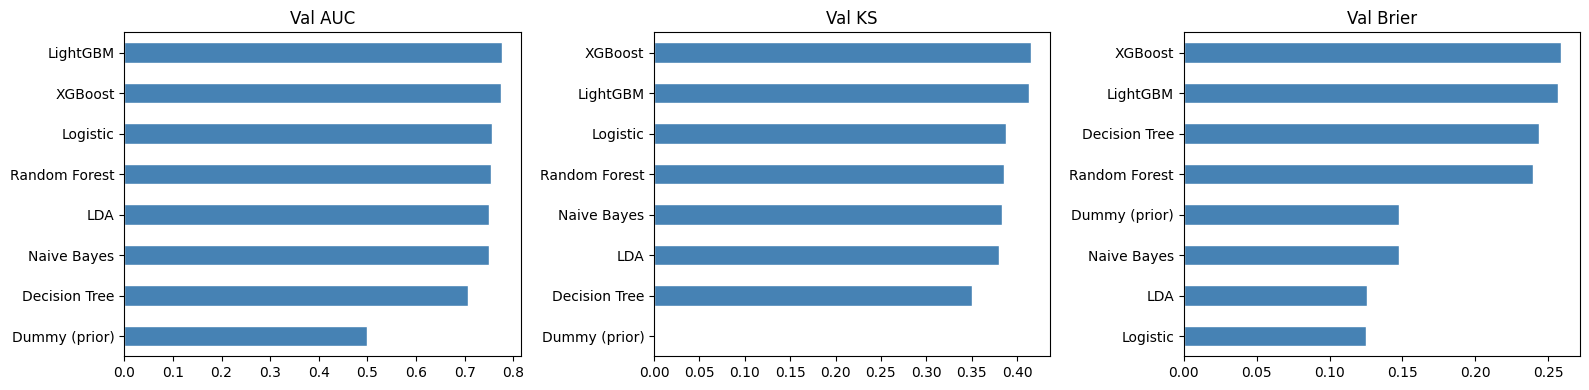

In [16]:
board = pd.DataFrame(RESULTS).T.sort_values("AUC", ascending=False)
print(board.round(4).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, m in zip(ax, ["AUC", "KS", "Brier"]):
    board[m].sort_values().plot.barh(ax=a, color="steelblue", edgecolor="white")
    a.set_title(f"Val {m}")
plt.tight_layout(); plt.show()

**Reading the table:** AUC / Gini / KS are directly comparable across all models — rank metrics are invariant to how the classes were weighted. **Brier is not** cross-comparable here: the natural-trained models (Logistic, LDA, NB) are already roughly calibrated, while the class-weighted / `scale_pos_weight` models (DT, RF, XGB, LightGBM) deliberately inflate their probabilities, so their raw Brier looks worse. That is exactly why we **select on AUC, then calibrate** before judging PD quality (§10).

Best by AUC: LightGBM


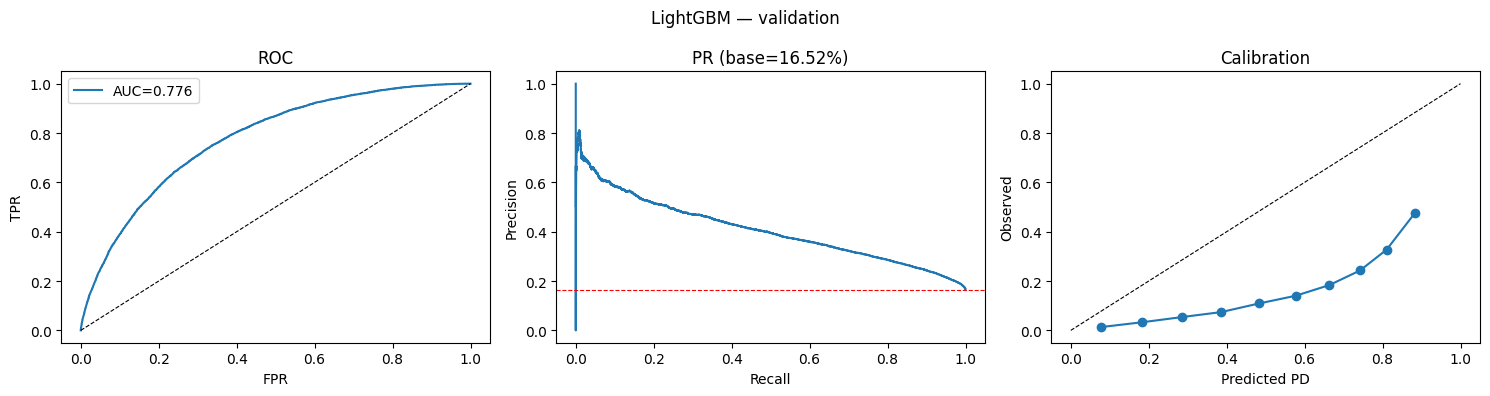

In [17]:
best_name = board.index[0]
best_model = {"Logistic": lr, "LDA": lda, "Naive Bayes": nb, "Decision Tree": dt,
              "Random Forest": rf, "XGBoost": xgb_best, "LightGBM": lgbm}[best_name]
print("Best by AUC:", best_name)
plot_eval(y_val, best_model.predict_proba(X_val)[:,1], f"{best_name} — validation")

## 10. Calibration

Rank-ordering (AUC) says nothing about whether a predicted "0.10" really defaults 10% of the time — but ECL needs exactly that. We fit both calibrators on val (Platt/sigmoid and isotonic) and compare Brier.

The vintage caveat from §1 is visible here: val is the 2007 crisis cohort, so a val-fitted calibrator learns crisis-level PDs. On the 2008–10 test set (lower base rate) the *level* will run high even though the *ranking* holds — a genuine model-risk point worth stating in the writeup.

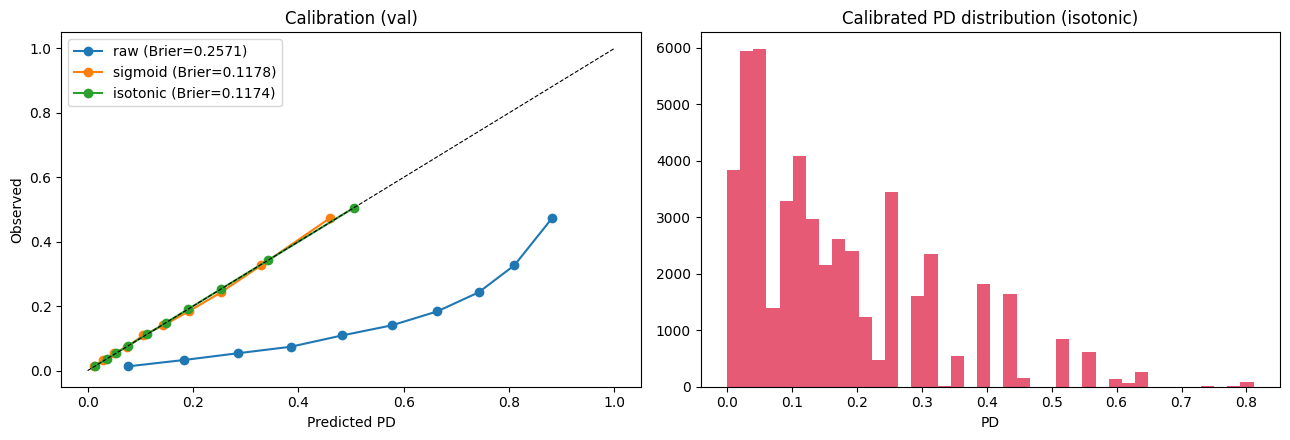

Brier: {'raw': 0.2571, 'sigmoid': 0.1178, 'isotonic': 0.1174}


In [18]:
from sklearn.frozen import FrozenEstimator   # sklearn >=1.6 replacement for cv="prefit"
frozen = FrozenEstimator(best_model)
cal_sig = CalibratedClassifierCV(frozen, method="sigmoid").fit(X_val, y_val)
cal_iso = CalibratedClassifierCV(frozen, method="isotonic").fit(X_val, y_val)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, mdl in [("raw", best_model), ("sigmoid", cal_sig), ("isotonic", cal_iso)]:
    p = mdl.predict_proba(X_val)[:,1]
    frac, mp = calibration_curve(y_val, p, n_bins=10, strategy="quantile")
    ax[0].plot(mp, frac, "o-", label=f"{name} (Brier={brier_score_loss(y_val,p):.4f})")
ax[0].plot([0,1],[0,1],"k--",lw=.8); ax[0].set_title("Calibration (val)")
ax[0].set_xlabel("Predicted PD"); ax[0].set_ylabel("Observed"); ax[0].legend()
ax[1].hist(cal_iso.predict_proba(X_val)[:,1], bins=40, color="crimson", alpha=.7)
ax[1].set_title("Calibrated PD distribution (isotonic)"); ax[1].set_xlabel("PD")
plt.tight_layout(); plt.show()

briers = {n: brier_score_loss(y_val, m.predict_proba(X_val)[:,1])
          for n, m in [("raw",best_model),("sigmoid",cal_sig),("isotonic",cal_iso)]}
calibrated = cal_iso if briers["isotonic"] <= briers["sigmoid"] else cal_sig
print("Brier:", {k: round(v,4) for k,v in briers.items()})

### Why not SMOTE? A calibration check

The earlier draft used SMOTE/ADASYN. Oversampling lifts recall at threshold 0.5 but distorts the base rate, so predicted PDs come out inflated — bad for ECL. Quick demonstration on the best model's family: class-weight vs SMOTE, compared on **Brier** (not just recall).

In [19]:
from imblearn.over_sampling import SMOTE
Xs, ys = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE).fit_resample(X_train, y_train)
lr_plain = LogisticRegression(max_iter=2000).fit(X_train, y_train)
lr_cw    = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train, y_train)
lr_smote = LogisticRegression(max_iter=2000).fit(Xs, ys)
for nm, m in [("natural", lr_plain), ("class_weight", lr_cw), ("SMOTE", lr_smote)]:
    p = m.predict_proba(X_val)[:,1]
    print(f"{nm:12} AUC={roc_auc_score(y_val,p):.4f}  Brier={brier_score_loss(y_val,p):.4f}  "
          f"mean_PD={p.mean():.3f} (actual {y_val.mean():.3f})")
print("\nclass_weight/SMOTE inflate mean PD far above the true rate -> worse Brier. "
      "We keep natural training + post-hoc calibration.")

natural      AUC=0.7563  Brier=0.1250  mean_PD=0.110 (actual 0.165)
class_weight AUC=0.7577  Brier=0.2534  mean_PD=0.504 (actual 0.165)
SMOTE        AUC=0.7570  Brier=0.1433  mean_PD=0.290 (actual 0.165)

class_weight/SMOTE inflate mean PD far above the true rate -> worse Brier. We keep natural training + post-hoc calibration.


## 11. Threshold tuning

Calibration fixes the probabilities; the threshold is the business decision on top. We show three principled choices on the **calibrated** PD and let the cost view drive the pick:

- **max-F1** — balances precision/recall symmetrically.
- **cost-based** — a missed default (FN) costs far more than a false alarm (FP); we use 10:1 as an illustration.
- **target-recall** — regulatory floor (e.g. catch ≥ 70% of defaults).

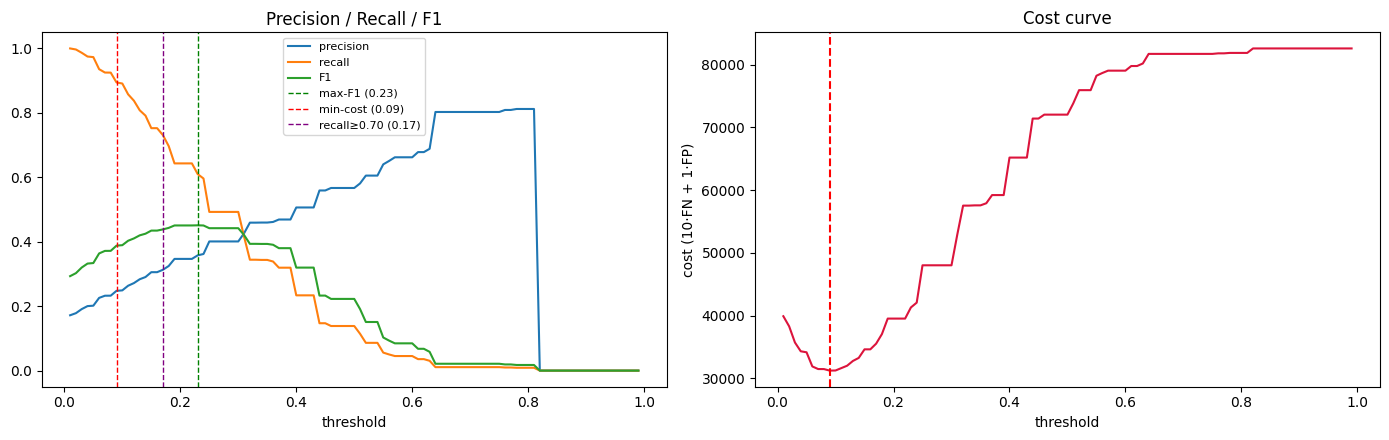

max-F1=0.23 | min-cost=0.09 | recall≥0.70=0.17
Chosen (min-cost): 0.09


In [20]:
pv = calibrated.predict_proba(X_val)[:,1]
grid = np.linspace(0.01, 0.99, 99)
rows = []
C_FN, C_FP = 10, 1
for t in grid:
    yh = (pv >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, yh).ravel()
    rows.append((t, precision_score(y_val,yh,zero_division=0), recall_score(y_val,yh,zero_division=0),
                 f1_score(y_val,yh,zero_division=0), C_FN*fn + C_FP*fp))
td = pd.DataFrame(rows, columns=["thr","precision","recall","f1","cost"])

t_f1   = td.loc[td["f1"].idxmax(), "thr"]
t_cost = td.loc[td["cost"].idxmin(), "thr"]
t_rec  = td.loc[(td["recall"] >= 0.70)].iloc[-1]["thr"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(td["thr"], td["precision"], label="precision")
ax[0].plot(td["thr"], td["recall"], label="recall")
ax[0].plot(td["thr"], td["f1"], label="F1")
for t, c, l in [(t_f1,"g","max-F1"),(t_cost,"r","min-cost"),(t_rec,"purple","recall≥0.70")]:
    ax[0].axvline(t, color=c, ls="--", lw=1, label=f"{l} ({t:.2f})")
ax[0].set_xlabel("threshold"); ax[0].legend(fontsize=8); ax[0].set_title("Precision / Recall / F1")
ax[1].plot(td["thr"], td["cost"], color="crimson"); ax[1].axvline(t_cost, color="r", ls="--")
ax[1].set_xlabel("threshold"); ax[1].set_ylabel(f"cost ({C_FN}·FN + {C_FP}·FP)"); ax[1].set_title("Cost curve")
plt.tight_layout(); plt.show()

THRESHOLD = float(t_cost)
print(f"max-F1={t_f1:.2f} | min-cost={t_cost:.2f} | recall≥0.70={t_rec:.2f}")
print(f"Chosen (min-cost): {THRESHOLD:.2f}")

## 12. Final test evaluation (once)

Best model + isotonic calibration + chosen threshold, applied to the untouched 2008–10 test set.

Model: LightGBM (calibrated) @ threshold 0.09

  AUC       : 0.7786
  Gini      : 0.5573
  KS        : 0.4153
  PR-AUC    : 0.1919
  Brier     : 0.0469
  Precision : 0.1278
  Recall    : 0.6673
  F1        : 0.2146
  Accuracy  : 0.7432

              precision    recall  f1-score   support

 Non-Default       0.98      0.75      0.85    142116
     Default       0.13      0.67      0.21      7884

    accuracy                           0.74    150000
   macro avg       0.55      0.71      0.53    150000
weighted avg       0.93      0.74      0.81    150000



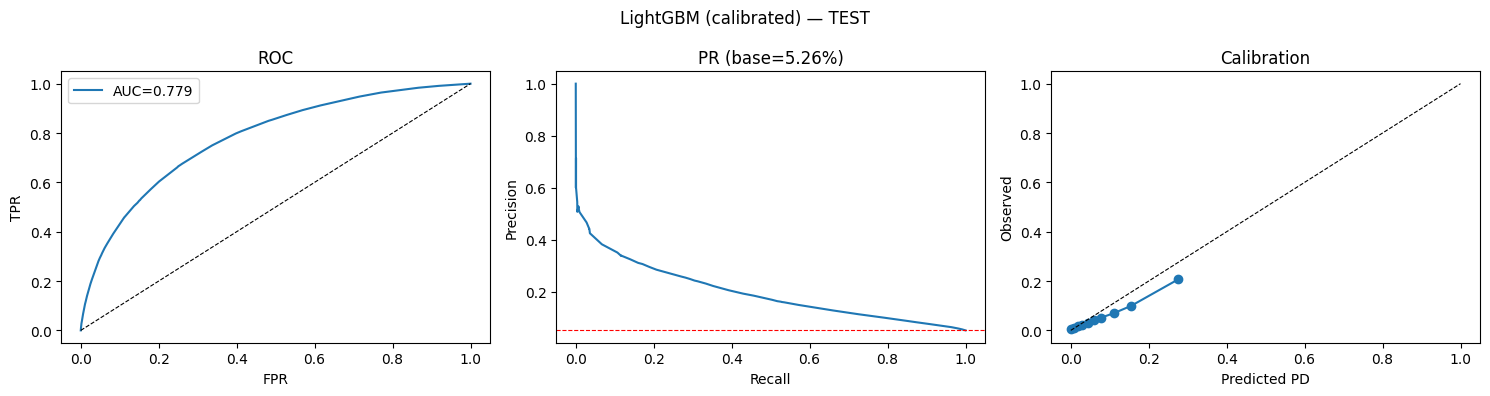

In [21]:
p_test = calibrated.predict_proba(X_test)[:,1]
final = metrics_at(y_test, p_test, thr=THRESHOLD)
print(f"Model: {best_name} (calibrated) @ threshold {THRESHOLD:.2f}\n")
for k, v in final.items():
    print(f"  {k:10}: {v:.4f}")
print()
yh_test = (p_test >= THRESHOLD).astype(int)
print(classification_report(y_test, yh_test, target_names=["Non-Default","Default"], zero_division=0))
plot_eval(y_test, p_test, f"{best_name} (calibrated) — TEST")

Note the expected pattern: AUC/Gini/KS on test hold up (ranking generalises across vintages), while the calibration panel shows the level bias from fitting the calibrator on the higher-default 2007 cohort. In production you would recalibrate on a recent window.

## 13. Explainability

Scorecard coefficients for the linear model, plus tree importances and SHAP for the winner — regulators expect both a transparent scorecard and an explanation for the ML challenger.

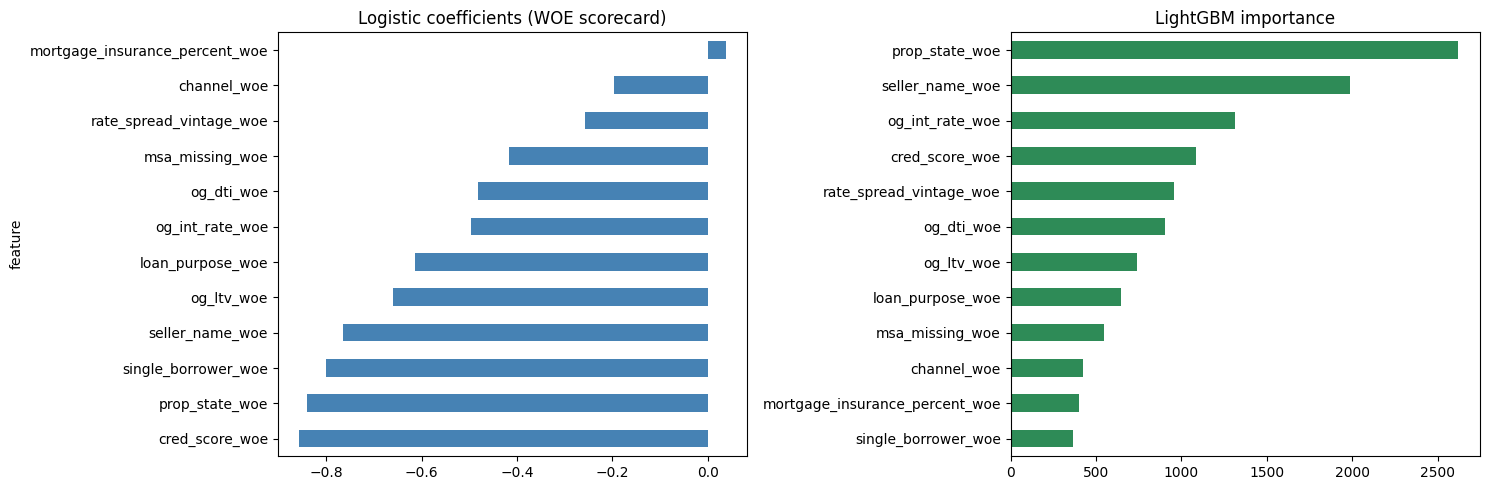

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
coef.set_index("feature")["coef"].plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Logistic coefficients (WOE scorecard)")
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=features).sort_values()
    imp.plot.barh(ax=ax[1], color="seagreen"); ax[1].set_title(f"{best_name} importance")
else:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc")
    pd.Series(pi.importances_mean, index=features).sort_values().plot.barh(ax=ax[1], color="seagreen")
    ax[1].set_title(f"{best_name} permutation importance")
plt.tight_layout(); plt.show()

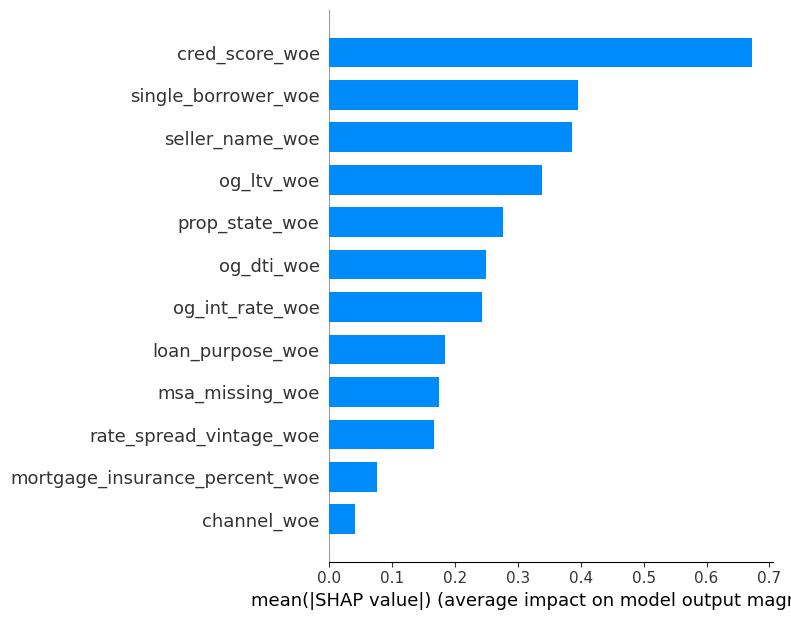

In [23]:
try:
    import shap
    expl = shap.TreeExplainer(best_model) if best_name in ("Random Forest","XGBoost","LightGBM") else None
    if expl is not None:
        Xs_ = X_val.sample(min(1000, len(X_val)), random_state=RANDOM_STATE)
        sv = expl.shap_values(Xs_)
        sv = sv[1] if isinstance(sv, list) else sv
        shap.summary_plot(sv, Xs_, plot_type="bar", show=True)
    else:
        print("Best model is linear — coefficients above already give the full explanation.")
except Exception as e:
    print("SHAP skipped:", str(e)[:80])

## 14. Save artifacts

In [24]:
joblib.dump({
    "model": best_model, "calibrator": calibrated, "threshold": THRESHOLD,
    "features": features, "best_name": best_name,
    "test_metrics": final,
}, "pd_model.pkl")
board.to_csv("model_leaderboard.csv")
print("Saved: pd_model.pkl, model_leaderboard.csv")
print(f"Shipping: {best_name} (isotonic-calibrated) @ threshold {THRESHOLD:.2f}")

Saved: pd_model.pkl, model_leaderboard.csv
Shipping: LightGBM (isotonic-calibrated) @ threshold 0.09
